## Random Forests Sınıflandırma (Model)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, log_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
diabetes = pd.read_csv('diabetes.csv')
df = diabetes.copy()
df.dropna()
y = df['Outcome']
X = df.drop(['Outcome'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [3]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [4]:
rf_model = RandomForestClassifier().fit(X_train, y_train)

In [5]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [6]:
#test hatasi

In [7]:
y_pred = rf_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7489177489177489

## Model Tuning

In [8]:
rf_params = {"max_depth" : [2,5,8,10],
             "max_features" : [2,5,8],
             "n_estimators" : [10,500,1000],
             "min_samples_split" : [2,5,10]}

In [9]:
#Cross Validation

In [10]:
rf_model = RandomForestClassifier()

rf_cv_model = GridSearchCV(rf_model,
                           rf_params, 
                           cv = 10,
                           n_jobs = -1,
                           verbose = 2)

In [11]:
rf_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 5, 8, 10], 'max_features': [2, 5, 8],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 500, 1000]},
             verbose=2)

In [12]:
print("En iyi parametre değerleri : " + str(rf_cv_model.best_params_))

En iyi parametre değerleri : {'max_depth': 8, 'max_features': 8, 'min_samples_split': 10, 'n_estimators': 1000}


In [13]:
#final model

In [14]:
rf_tuned = RandomForestClassifier(max_depth = 10, 
                                  max_features = 5, 
                                  min_samples_split = 10,
                                  n_estimators = 10)

In [15]:
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features=5, min_samples_split=10,
                       n_estimators=10)

In [16]:
#final test hatasi

In [17]:
y_pred = rf_tuned.predict(X_test)

In [18]:
accuracy_score(y_test, y_pred)

0.7445887445887446

In [19]:
#Degisken Onem duzeyleri

In [24]:
Importance = pd.DataFrame({"Importance" : rf_tuned.feature_importances_ * 100},
                          index = X_train.columns)

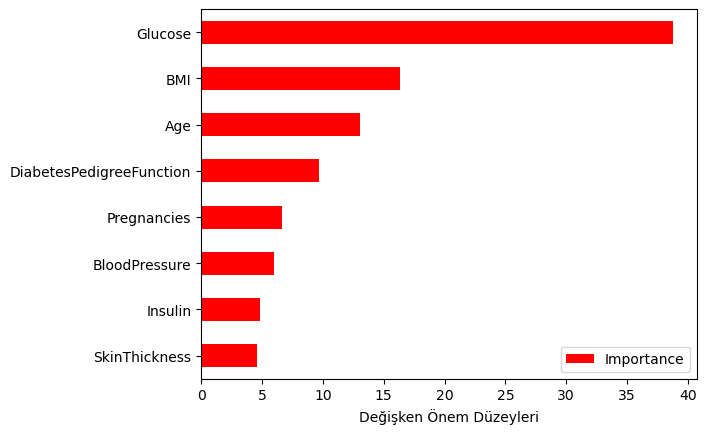

In [26]:
Importance.sort_values(by = "Importance",
                       axis = 0,
                       ascending = True).plot(kind = "barh", color = "r")

plt.xlabel("Değişken Önem Düzeyleri");